In [9]:
import numpy as np 
import pandas as pd 
import matplotlib.pyplot as plt
df = pd.read_csv("exchange_rate.csv")
df

,date,Ex_rate
0,01-01-1990 00:00,0.785500
1,02-01-1990 00:00,0.781800
2,03-01-1990 00:00,0.786700
3,04-01-1990 00:00,0.786000
4,05-01-1990 00:00,0.784900
...,...,...
7583,06-10-2010 00:00,0.718494
7584,07-10-2010 00:00,0.721839
7585,08-10-2010 00:00,0.723197
7586,09-10-2010 00:00,0.720825


In [17]:
df['date'] = pd.to_datetime(df['date'], dayfirst=True)
df.set_index('date', inplace=True)

In [18]:
df.info()

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 7588 entries, 1990-01-01 to 2010-10-10
Data columns (total 1 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   Ex_rate  7588 non-null   float64
dtypes: float64(1)
memory usage: 118.6 KB


In [20]:
df.describe()

,Ex_rate
count,7588.000000
mean,0.776974
std,0.136620
min,0.483297
25%,0.701422
50%,0.761377
75%,0.873477
max,1.102536


In [24]:
df.isnull().sum()

Ex_rate    0
dtype: int64

array([[<Axes: title={'center': 'Ex_rate'}>]], dtype=object)

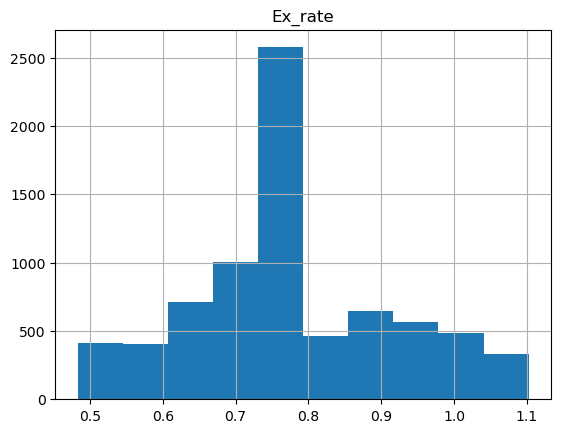

In [6]:
df.hist()

<Axes: xlabel='date'>

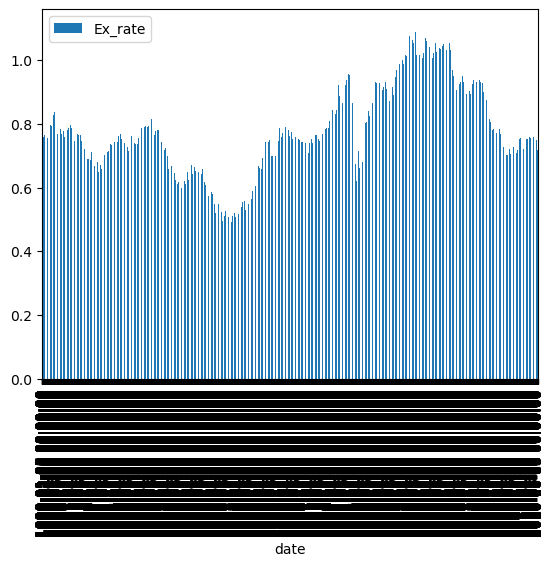

In [22]:
df.plot(kind='bar')

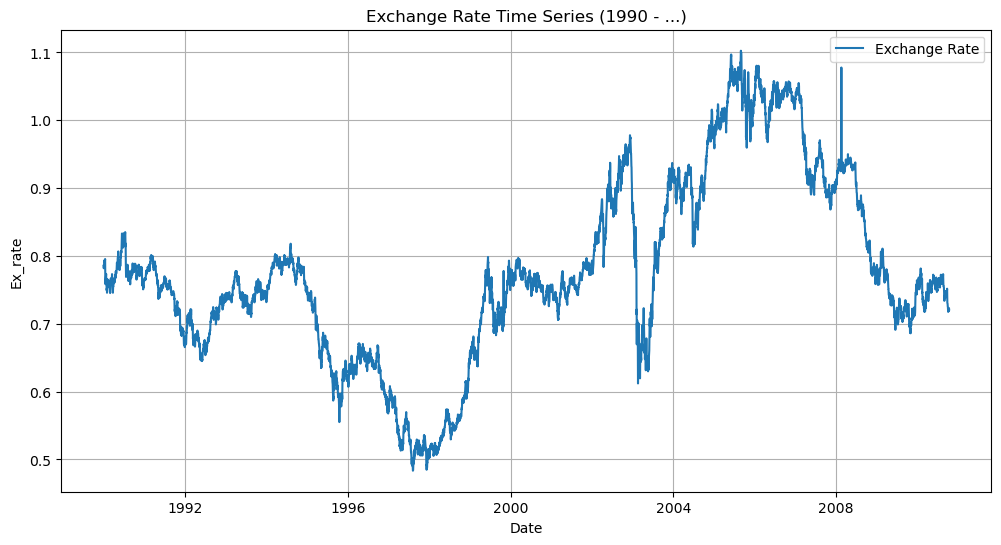

In [23]:
plt.figure(figsize=(12, 6))
plt.plot(df['Ex_rate'], label='Exchange Rate')
plt.title('Exchange Rate Time Series (1990 - ...)')
plt.xlabel('Date')
plt.ylabel('Ex_rate')
plt.grid(True)
plt.legend()
plt.savefig('exchange_rate_trend.png')

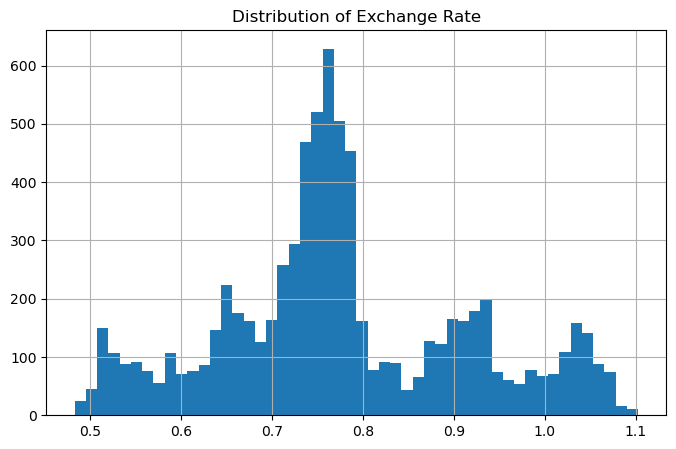

In [26]:
plt.figure(figsize=(8, 5))
df['Ex_rate'].hist(bins=50)
plt.title('Distribution of Exchange Rate')
plt.savefig('exchange_rate_dist.png')
df.to_csv('processed_exchange_rate.csv')

In [29]:
from statsmodels.tsa.stattools import adfuller
def check_stationarity(timeseries):
    result = adfuller(timeseries, autolag='AIC')
    print(f'ADF Statistic: {result[0]}')
    print(f'p-value: {result[1]}')
    for key, value in result[4].items():
        print(f'Critical Value ({key}): {value}')
    if result[1] <= 0.05:
        print("The series is stationary.")
    else:
        print("The series is non-stationary.")

print("Original Series Stationarity Check:")
check_stationarity(df['Ex_rate'])
df['diff_1'] = df['Ex_rate'].diff().dropna()
print("\nFirst Differenced Series Stationarity Check:")
check_stationarity(df['diff_1'].dropna())

Original Series Stationarity Check:
ADF Statistic: -1.6649941807381343
p-value: 0.44923273535979974
Critical Value (1%): -3.4312123140180137
Critical Value (5%): -2.861921078147796
Critical Value (10%): -2.5669728434336108
The series is non-stationary.

First Differenced Series Stationarity Check:
ADF Statistic: -99.39343120118627
p-value: 0.0
Critical Value (1%): -3.4312123140180137
Critical Value (5%): -2.861921078147796
Critical Value (10%): -2.5669728434336108
The series is stationary.


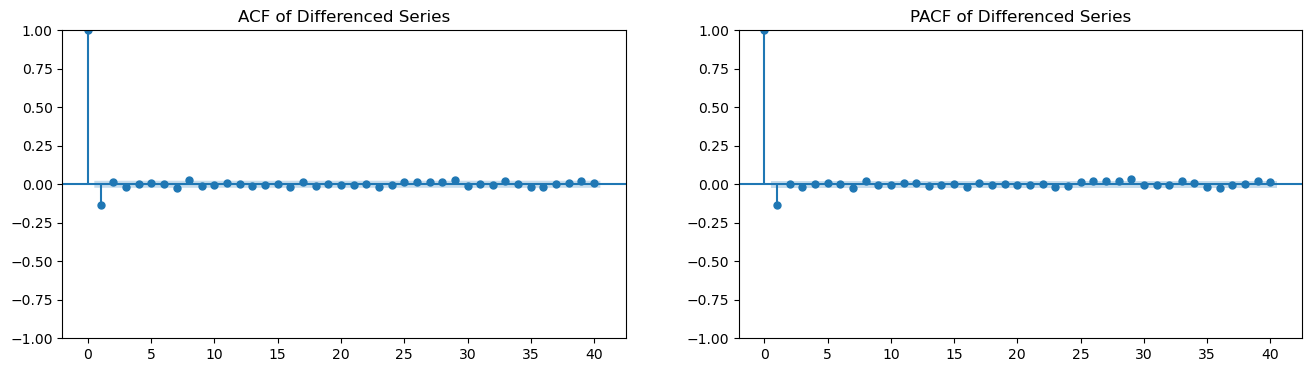

In [33]:
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
fig, axes = plt.subplots(1, 2, figsize=(16, 4))
plot_acf(df['diff_1'].dropna(), ax=axes[0], lags=40)
axes[0].set_title('ACF of Differenced Series')
plot_pacf(df['diff_1'].dropna(), ax=axes[1], lags=40)
axes[1].set_title('PACF of Differenced Series')
plt.savefig('acf_pacf_plots.png')

train, test = df['Ex_rate'][0:train_size], df['Ex_rate'][train_size:len(df)]

C:\Users\amarm\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)
C:\Users\amarm\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)
C:\Users\amarm\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)


                               SARIMAX Results                                
Dep. Variable:                Ex_rate   No. Observations:                 7208
Model:                 ARIMA(1, 1, 1)   Log Likelihood               26570.025
Date:                Thu, 12 Feb 2026   AIC                         -53134.050
Time:                        18:25:56   BIC                         -53113.401
Sample:                    01-01-1990   HQIC                        -53126.945
                         - 09-25-2009                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1         -0.1185      0.046     -2.559      0.011      -0.209      -0.028
ma.L1         -0.0137      0.046     -0.295      0.768      -0.105       0.077
sigma2      3.675e-05   1.04e-07    353.589      0.0

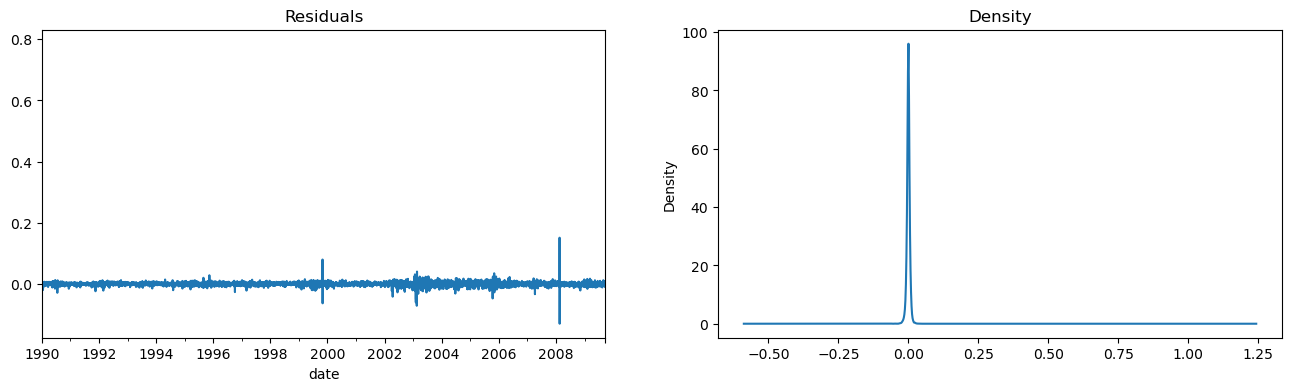

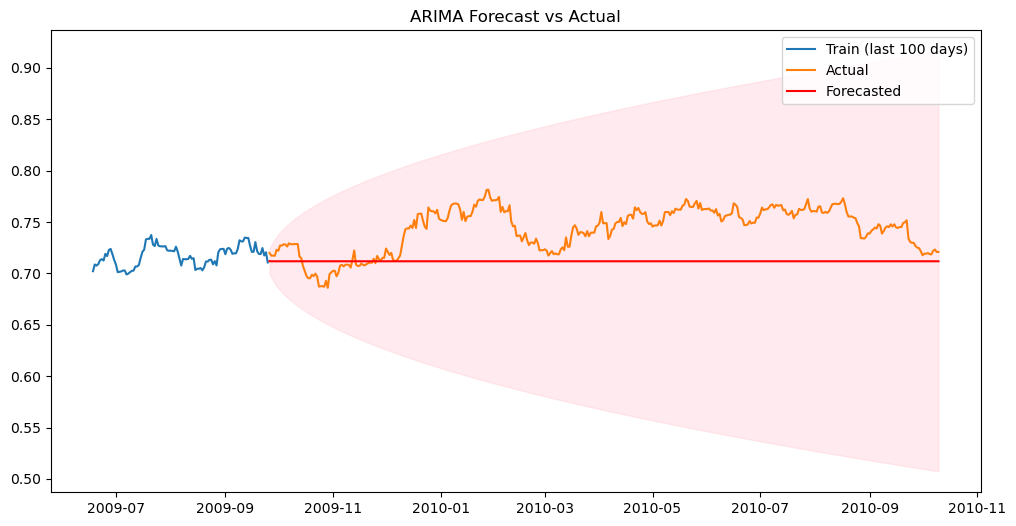

In [35]:
from statsmodels.tsa.arima.model import ARIMA
model = ARIMA(train, order=(1, 1, 1))
model_fit = model.fit()
print(model_fit.summary())

residuals = model_fit.resid
fig, axes = plt.subplots(1, 2, figsize=(16, 4))
residuals.plot(title="Residuals", ax=axes[0])
residuals.plot(kind='kde', title='Density', ax=axes[1])
plt.savefig('residual_diagnostics.png')

forecast_steps = len(test)
forecast_result = model_fit.get_forecast(steps=forecast_steps)
forecast_mean = forecast_result.predicted_mean
conf_int = forecast_result.conf_int()

plt.figure(figsize=(12, 6))
plt.plot(train.index[-100:], train.values[-100:], label='Train (last 100 days)')
plt.plot(test.index, test.values, label='Actual')
plt.plot(test.index, forecast_mean, label='Forecasted', color='red')
plt.fill_between(test.index, conf_int.iloc[:, 0], conf_int.iloc[:, 1], color='pink', alpha=0.3)
plt.title('ARIMA Forecast vs Actual')
plt.legend()
plt.savefig('forecast_plot.png')

In [48]:
from sklearn.metrics import mean_absolute_error, mean_squared_error
mae = mean_absolute_error(test, forecast_mean)
rmse = np.sqrt(mean_squared_error(test, forecast_mean))
print(f"MAE: {mae}")
print(f"RMSE: {rmse}")

MAE: 0.03321272140093946
RMSE: 0.03775198178795435


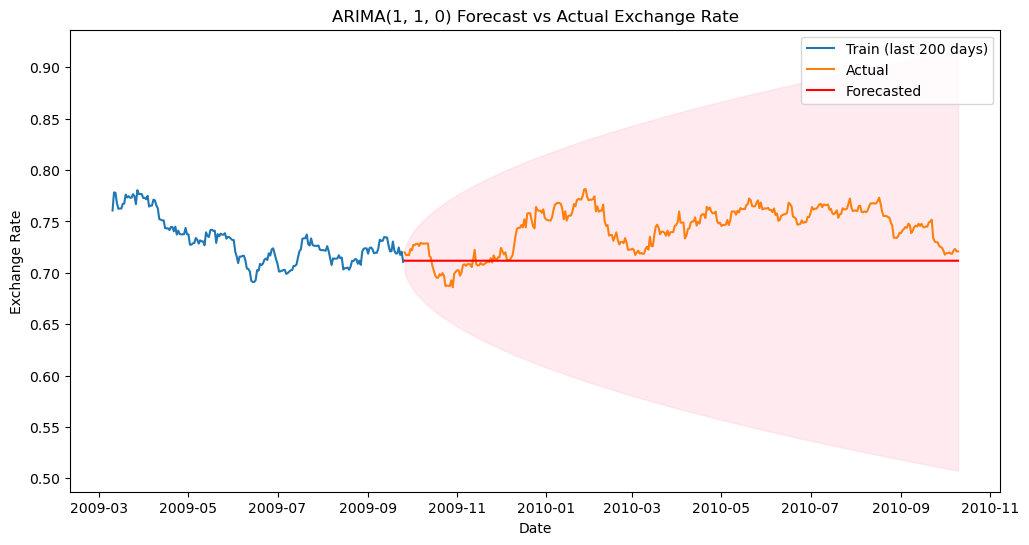

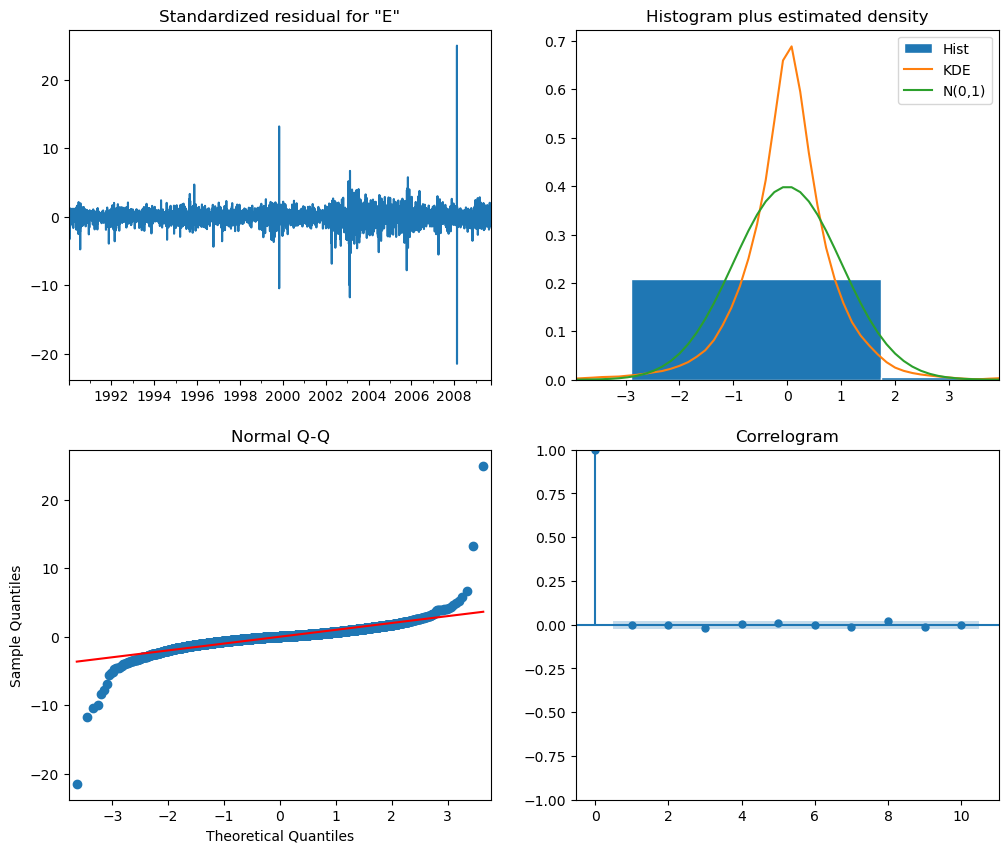

In [49]:
plt.figure(figsize=(12, 6))
plt.plot(train.index[-200:], train.values[-200:], label='Train (last 200 days)')
plt.plot(test.index, test.values, label='Actual')
plt.plot(test.index, forecast_mean, label='Forecasted', color='red')
plt.fill_between(test.index, conf_int.iloc[:, 0], conf_int.iloc[:, 1], color='pink', alpha=0.3)
plt.title('ARIMA(1, 1, 0) Forecast vs Actual Exchange Rate')
plt.xlabel('Date')
plt.ylabel('Exchange Rate')
plt.legend()
plt.savefig('final_forecast_plot.png')
fig = model_refined_fit.plot_diagnostics(figsize=(12, 10))
plt.savefig('final_diagnostics.png')

In [56]:
es_model = ExponentialSmoothing(train, trend='add', seasonal=None)
es_fit = es_model.fit()
es_forecast = es_fit.forecast(steps=len(test))

C:\Users\amarm\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)


In [57]:
arima_mae = mean_absolute_error(test, arima_forecast)
arima_rmse = np.sqrt(mean_squared_error(test, arima_forecast))
arima_mape = mean_absolute_percentage_error(test, arima_forecast)
# Metrics for Exponential Smoothing
es_mae = mean_absolute_error(test, es_forecast)
es_rmse = np.sqrt(mean_squared_error(test, es_forecast))
es_mape = mean_absolute_percentage_error(test, es_forecast)

In [59]:
metrics_comparison = pd.DataFrame({
    'Metric': ['MAE', 'RMSE', 'MAPE (%)'],
    'ARIMA(1,1,0)': [arima_mae, arima_rmse, arima_mape],
    'Exp Smoothing (Holt)': [es_mae, es_rmse, es_mape]
})
print(metrics_comparison)

     Metric  ARIMA(1,1,0)  Exp Smoothing (Holt)
0       MAE      0.033221              0.046873
1      RMSE      0.037761              0.052382
2  MAPE (%)      0.044098              0.062294


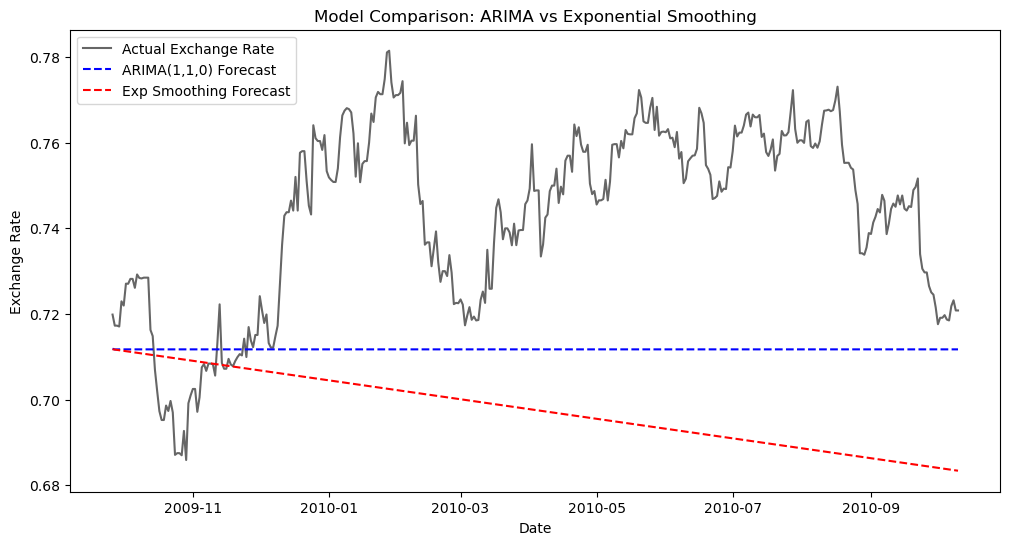

In [60]:
plt.figure(figsize=(12, 6))
plt.plot(test.index, test.values, label='Actual Exchange Rate', color='black', alpha=0.6)
plt.plot(test.index, arima_forecast, label='ARIMA(1,1,0) Forecast', color='blue', linestyle='--')
plt.plot(test.index, es_forecast, label='Exp Smoothing Forecast', color='red', linestyle='--')
plt.title('Model Comparison: ARIMA vs Exponential Smoothing')
plt.xlabel('Date')
plt.ylabel('Exchange Rate')
plt.legend()
plt.savefig('model_comparison_plot.png')
# Save the metrics to CSV for the user
metrics_comparison.to_csv('model_metrics_comparison.csv', index=False)

1. Error Metrics Comparison.
These are the metrics i used
->Mean Absolute Error (MAE), Root Mean Squared Error (RMSE), and Mean Absolute Percentage Error (MAPE).
2.Model Comparison.
->Performance: Outperformed Exponential Smoothing across all metrics. It yielded a lower MAPE ($4.41\%$), indicating higher accuracy.
3.Conclusion.
->Based on the results, the ARIMA(1, 1, 0) model is the superior choice for this specific exchange rate dataset. It provided more reliable forecasts with significantly lower error margins (RMSE of $0.0378$ vs. $0.0524$).

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from statsmodels.tsa.stattools import adfuller
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.tsa.arima.model import ARIMA
from statsmodels.tsa.holtwinters import ExponentialSmoothing
from sklearn.metrics import mean_absolute_error, mean_squared_error

# --- 1. DATA PREPARATION ---
# Load the dataset and set date as index
df = pd.read_csv('exchange_rate.csv')
df['date'] = pd.to_datetime(df['date'], dayfirst=True)
df.set_index('date', inplace=True)

# Visualize the time series
plt.figure(figsize=(12, 6))
plt.plot(df['Ex_rate'], label='Exchange Rate')
plt.title('Exchange Rate Over Time')
plt.savefig('exchange_rate_plot.png')

# --- 2. STATIONARITY CHECK ---
# ADF test to check if differencing is needed
def check_stationarity(ts):
    res = adfuller(ts.dropna())
    return res[1] # Return p-value

print(f"Original p-value: {check_stationarity(df['Ex_rate'])}")
# p > 0.05, taking first difference
df['diff_1'] = df['Ex_rate'].diff()
print(f"Differenced p-value: {check_stationarity(df['diff_1'])}")

# --- 3. PARAMETER SELECTION ---
# Plot ACF and PACF for parameter estimation
fig, ax = plt.subplots(1, 2, figsize=(15, 5))
plot_acf(df['diff_1'].dropna(), ax=ax[0])
plot_pacf(df['diff_1'].dropna(), ax=ax[1])
plt.savefig('acf_pacf_plots.png')

# --- 4. MODEL FITTING ---
# Split into train (95%) and test (5%)
train_idx = int(len(df) * 0.95)
train, test = df['Ex_rate'][:train_idx], df['Ex_rate'][train_idx:]

# Fit ARIMA(1, 1, 0) - Chosen based on significance of AR(1)
arima_model = ARIMA(train, order=(1, 1, 0))
arima_res = arima_model.fit()

# --- 5. DIAGNOSTICS ---
# Check residuals for white noise
fig = arima_res.plot_diagnostics(figsize=(12, 8))
plt.savefig('final_diagnostics.png')

# --- 6. FORECASTING & EVALUATION ---
# Forecast both models
arima_pred = arima_res.forecast(steps=len(test))

es_model = ExponentialSmoothing(train, trend='add').fit()
es_pred = es_model.forecast(steps=len(test))

# Metrics
def get_metrics(true, pred):
    mae = mean_absolute_error(true, pred)
    rmse = np.sqrt(mean_squared_error(true, pred))
    mape = np.mean(np.abs((true - pred) / true)) * 100
    return mae, rmse, mape

arima_metrics = get_metrics(test, arima_pred)
es_metrics = get_metrics(test, es_pred)

# --- 7. COMPARISON PLOT ---
plt.figure(figsize=(12, 6))
plt.plot(test.index, test, label='Actual', color='black')
plt.plot(test.index, arima_pred, label='ARIMA(1,1,0)', linestyle='--')
plt.plot(test.index, es_pred, label='Exp Smoothing', linestyle=':')
plt.title('Model Comparison: Forecast vs Actual')
plt.legend()
plt.savefig('model_comparison_plot.png')

print(f"ARIMA Metrics: MAE={arima_metrics[0]:.4f}, RMSE={arima_metrics[1]:.4f}, MAPE={arima_metrics[2]:.2f}%")
print(f"ES Metrics: MAE={es_metrics[0]:.4f}, RMSE={es_metrics[1]:.4f}, MAPE={es_metrics[2]:.2f}%")

---->>>> These are the steps that i used to solve the question.